# Static Plotting Examples

This notebook demonstrates the usage of `adataviz` static plotting functions:
- `plot_categorical` – UMAP colored by categorical annotations
- `plot_gene` – UMAP colored by gene expression + violin plot
- `stacked_barplot` – cell type composition across groups

In [1]:
sys.path.append(os.path.expanduser("~/Projects/Github/adataviz"))
import adataviz as av
import anndata

In [2]:
# Path to the example AnnData file
adata_path = (
    "~/Projects/LabData/BasalGanglia/10xMultiome/HMBA.Group.downsample_1500.h5ad"
)

# Quick look at the data
adata = anndata.read_h5ad(os.path.expanduser(adata_path), backed="r")
print(f"Shape: {adata.shape}")
print(
    f"Categorical columns: Neighborhood ({adata.obs['Neighborhood'].nunique()}), "
    f"Class ({adata.obs['Class'].nunique()}), "
    f"Subclass ({adata.obs['Subclass'].nunique()}), "
    f"Group ({adata.obs['Group'].nunique()})"
)
print(f"Embeddings: {list(adata.obsm.keys())}")
adata.file.close()

Shape: (70134, 36601)
Categorical columns: Neighborhood (4), Class (12), Subclass (36), Group (60)
Embeddings: ['X_scVI', 'X_umap']


## 1. `plot_categorical` – Categorical UMAP (or TSNE)

Plot a UMAP embedding colored by a categorical variable (e.g. `Class`),
with labeled cluster centroids.

/gale/netapp/home2/wding/Projects/Github/adataviz/adataviz/utils.py:785: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for text, sub_df in data.groupby(anno_col):


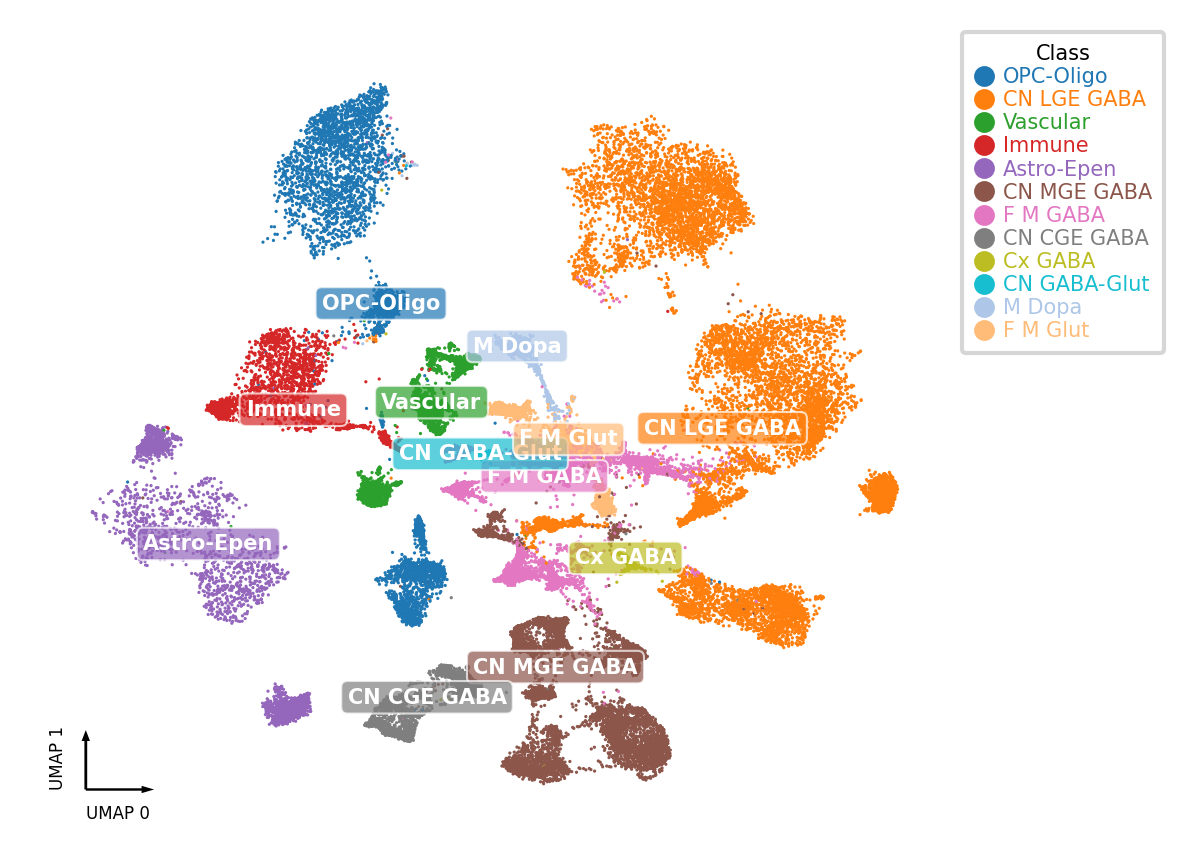

<Axes: >

In [3]:
# Basic usage: color by Class with text annotation
av.pl.plot_categorical(
    adata=adata_path,
    basis="umap",
    groupby="Class",
    coding=False,
    text_anno="Class",
    # save="Class.umap.no_text.pdf",
    palette=None,  # legend_kws=dict(bbox_to_anchor=(0.1,0.9),ncol=2),
    axis_format="tiny",
    figsize=(4, 3.5),  # rectangle_marker=True
    show_legend=True,
)

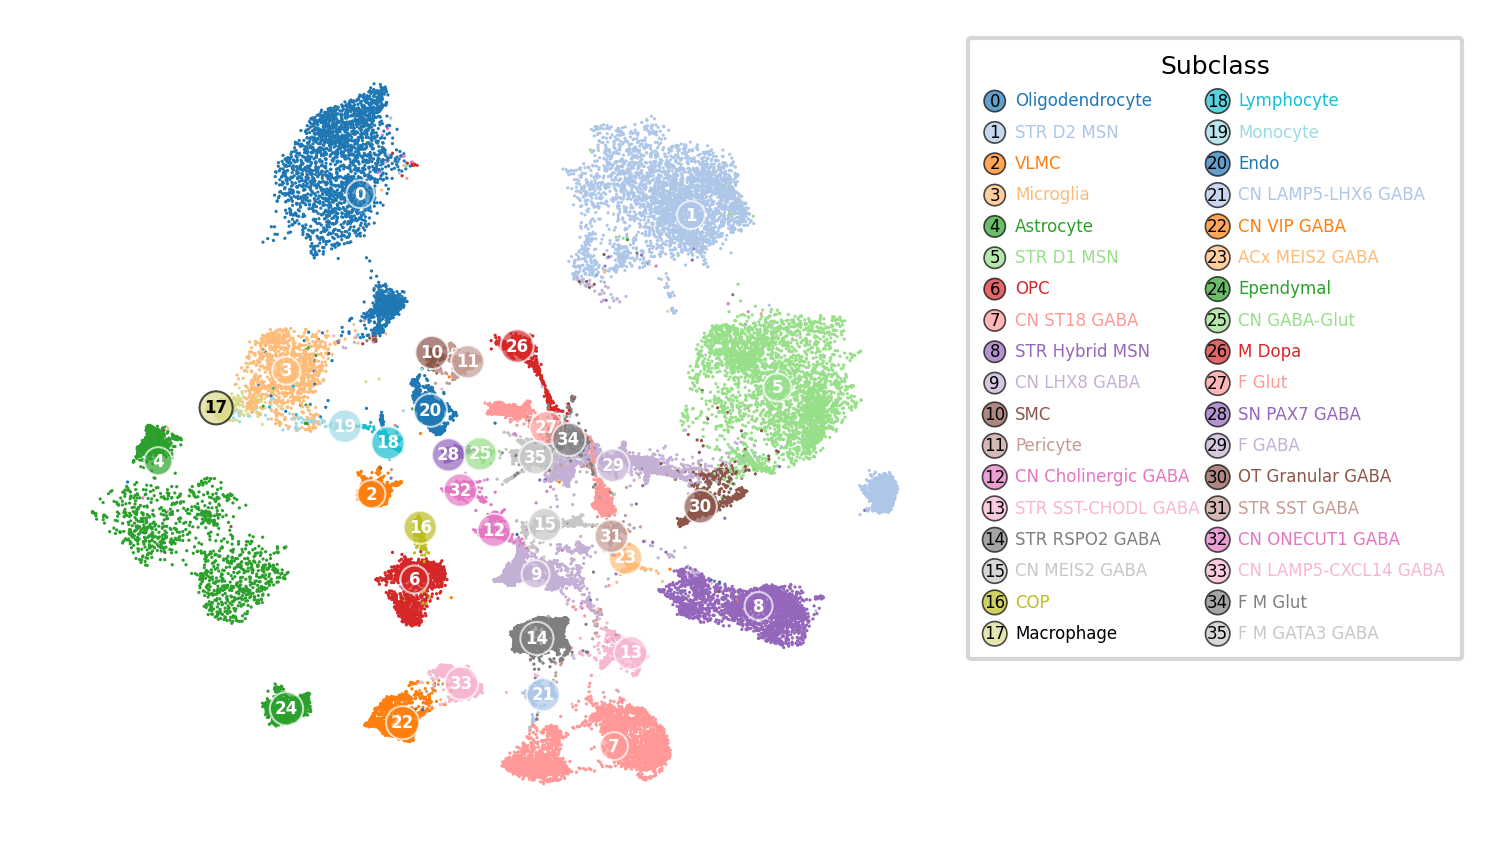

<Axes: >

In [4]:
# Color by Subclass with more legend columns and coding annotation
av.pl.plot_categorical(
    adata=adata_path,
    basis="umap",
    groupby="Subclass",
    coding=True,
    text_anno="Subclass",
    # save="Subclass.umap.no_text.pdf",
    palette=None,
    fontsize=4,
    legend_fontsize=4,
    legend_title_fontsize=6,
    legend_kws=dict(
        ncol=2,  # bbox_to_anchor=(0.7,0.9)
        labelspacing=0.8,
        borderpad=1,
        handletextpad=0.8,
    ),
    axis_format=None,
    figsize=(4, 3.5),
    show_legend=True,
)

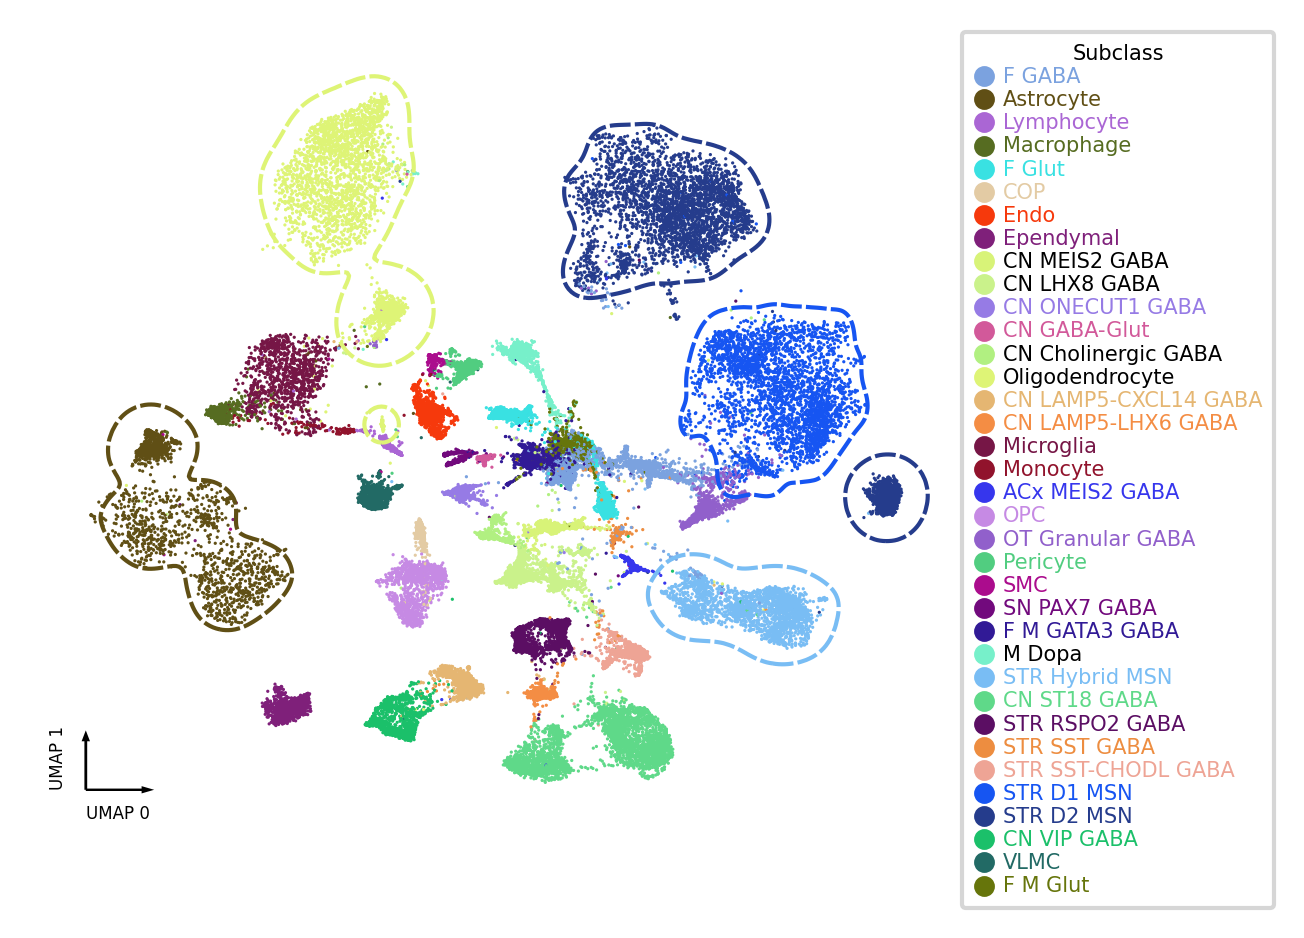

<Axes: >

In [5]:
# Basic usage: color by Subclass with outline (for selected cell types only)
palette = (
    adata.obs.drop_duplicates("Subclass")
    .set_index("Subclass")["color_hex_subclass"]
    .to_dict()
)
av.pl.plot_categorical(
    adata=adata_path,
    basis="umap",
    groupby="Subclass",
    coding=False,
    text_anno=None,
    outline=adata.obs.Subclass.apply(
        lambda x: x
        if x
        in [
            "STR D1 MSN",
            "STR D2 MSN",
            "STR Hybrid MSN",
            "Astrocyte",
            "Oligodendrocyte",
        ]
        else None
    ),
    outline_kws={
        "linewidth": 1,
        "palette": palette,
        "linestyles": "densely dashed",
        "single_contour_pad": 1,
        "threshold": 0.04,
        "smooth_sigma": 5,
    },
    palette=palette,  # legend_kws=dict(bbox_to_anchor=(0.1,0.9),ncol=2),
    axis_format="tiny",
    figsize=(4, 3.5),  # rectangle_marker=True
    show_legend=True,
)

## 2. `plot_gene` – Gene Expression on UMAP + Violin Plot

Plot a single gene's expression on the UMAP embedding.
When `groupby` is provided, a violin plot is also generated.

/gale/netapp/home2/wding/Projects/Github/adataviz/adataviz/pl/expression.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


/gale/netapp/home2/wding/Projects/Github/adataviz/adataviz/pl/expression.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


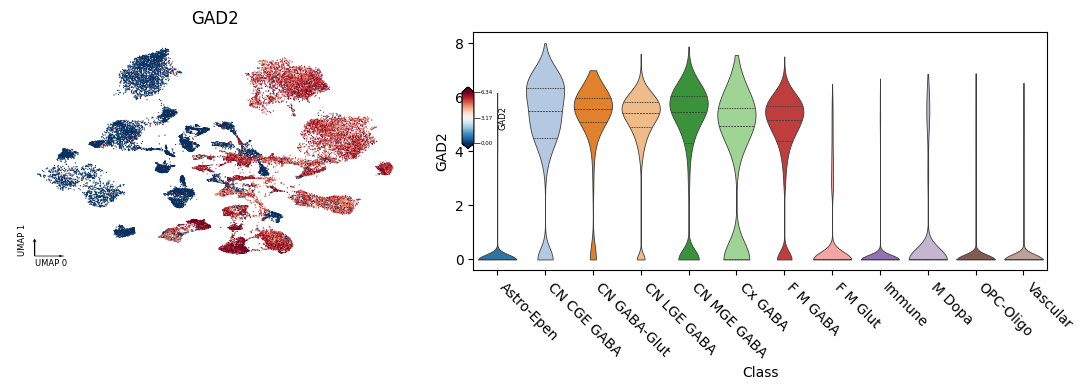

In [6]:
# Plot GAD2 (GABAergic neuron marker) on UMAP, plus a per-Class boxplot.
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={'width_ratios': [1, 1.4]})
av.pl.plot_gene(adata=adata_path, gene="GAD2", basis="umap", cmap="RdBu_r", ax=axes[0], show=False)
_ = av.pl.boxplot(
    adata=anndata.read_h5ad(os.path.expanduser(adata_path))[:, ["GAD2"]],
    genes="GAD2", groupby="Class", kind="violin", ax=axes[1], show=False,
)
plt.show()


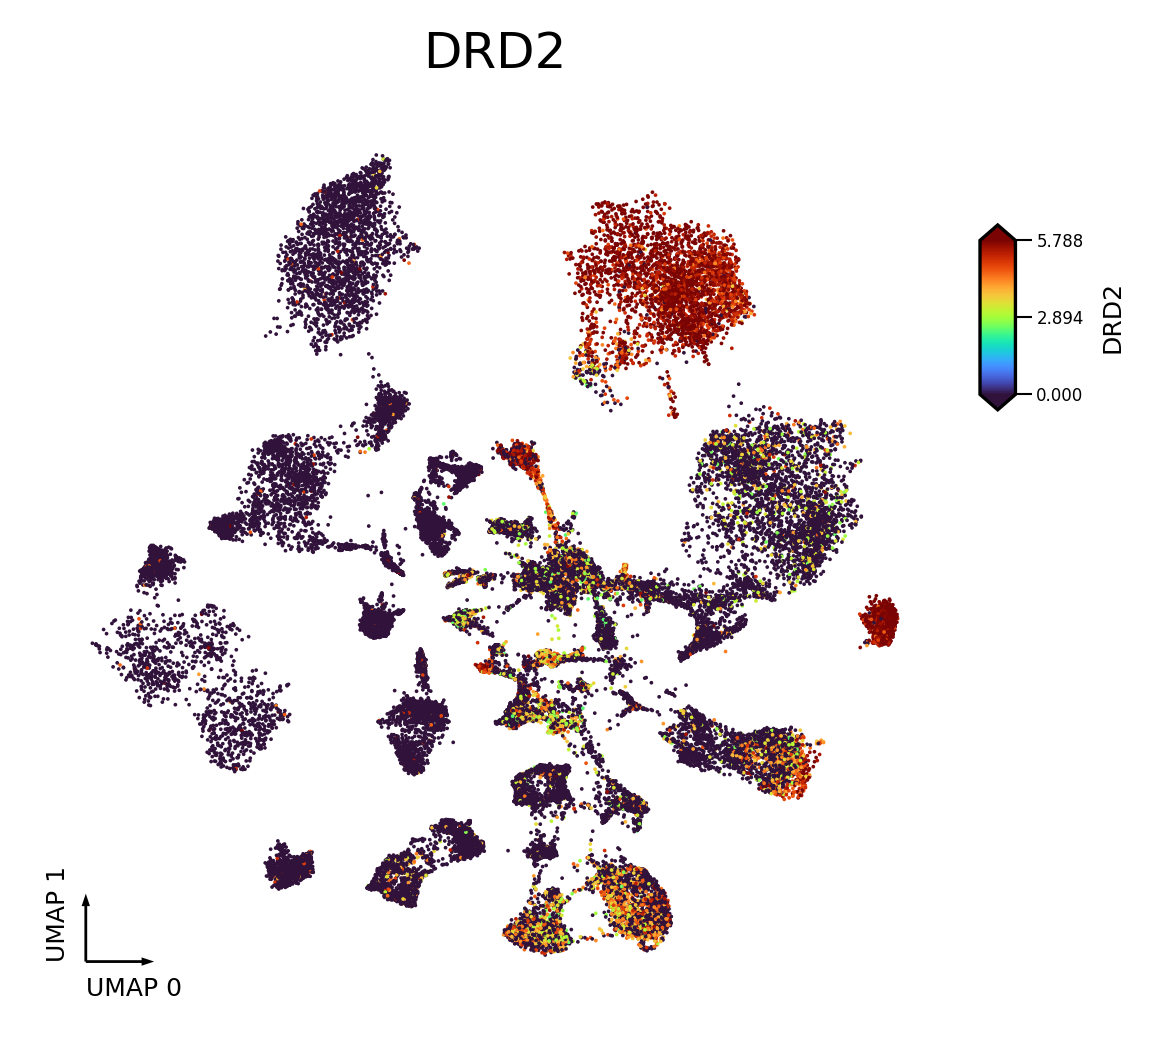

<Axes: title={'center': 'DRD2'}>

In [7]:
# Plot DRD2 (D2 receptor) on UMAP only.
av.pl.plot_gene(adata=adata_path, gene="DRD2", basis="umap", cmap="turbo")


## 3. `stacked_barplot` – Cell Type Composition

Show the proportion of cell types (e.g. `Class`) within each anatomical region or donor.

In [8]:
# Load obs for barplot/pieplot (these accept a DataFrame directly)
adata = anndata.read_h5ad(os.path.expanduser(adata_path), backed="r")
obs = adata.obs.copy()
adata.file.close()

# Build color palettes from the existing color columns in obs
color_palettes = {}
for level in ["neighborhood", "class", "subclass", "group"]:
    col_name = level.capitalize() if level != "neighborhood" else "Neighborhood"
    hex_col = f"color_hex_{level}"
    if hex_col in obs.columns:
        color_palettes[col_name] = (
            obs.drop_duplicates(col_name).set_index(col_name)[hex_col].to_dict()
        )

print("Available color palettes:", list(color_palettes.keys()))

Available color palettes: ['Neighborhood', 'Class', 'Subclass', 'Group']


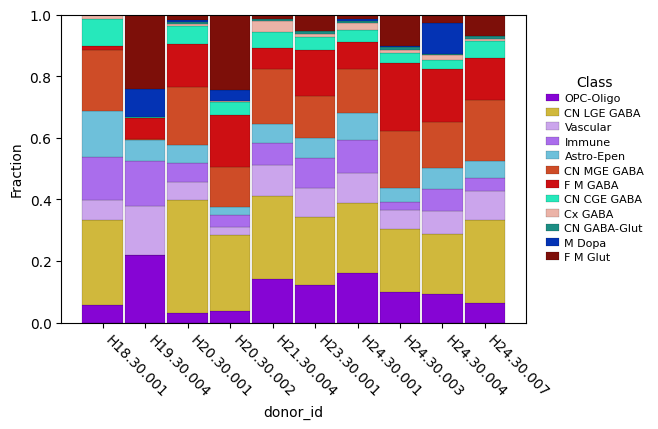

<Axes: xlabel='donor_id', ylabel='Fraction'>

In [9]:
# Stacked bar plot: Class composition per donor
av.pl.bar_plot(
    adata=obs,
    groupby="Class",
    split_by="donor_id",
    palette=color_palettes.get("Class"),
    figsize=(6, 4),
    show=True,
)


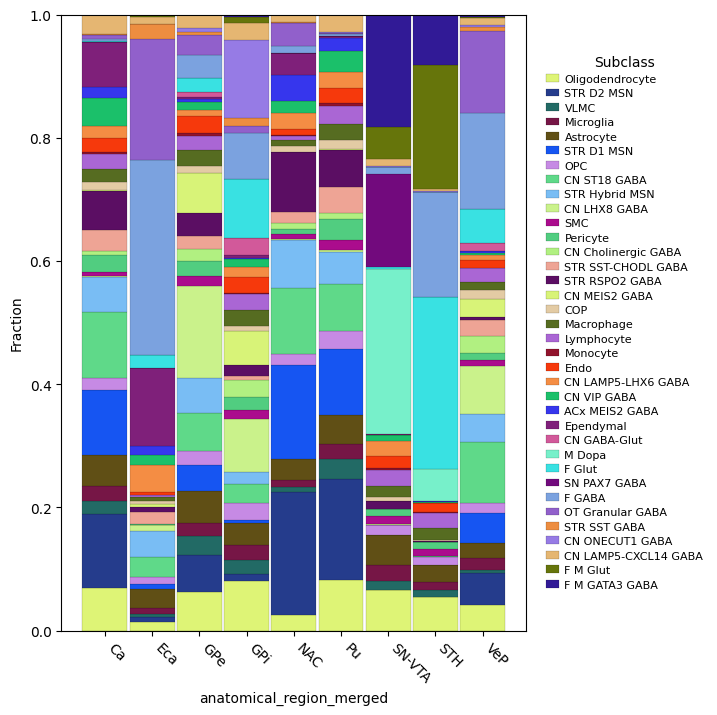

<Axes: xlabel='anatomical_region_merged', ylabel='Fraction'>

In [10]:
# Stacked bar plot: Subclass composition per anatomical region
av.pl.bar_plot(
    adata=obs,
    groupby="Subclass",
    split_by="anatomical_region_merged",
    palette=color_palettes.get("Subclass"),
    figsize=(6, 8),
    show=True,
)


/gale/netapp/home2/wding/Projects/Github/adataviz/adataviz/pl/expression.py:486: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  use.obs[groupby] = obs.loc[use.obs_names, groupby].tolist()


/gale/netapp/home2/wding/Software/miniconda3/envs/m3c/lib/python3.9/site-packages/PyComplexHeatmap/dotHeatmap.py:354: FutureWarning: The provided callable <function mean at 0x7f9af027cca0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data2d = data.pivot_table(
/gale/netapp/home2/wding/Software/miniconda3/envs/m3c/lib/python3.9/site-packages/PyComplexHeatmap/dotHeatmap.py:373: FutureWarning: The provided callable <function mean at 0x7f9af027cca0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.kwargs["s"] = data.pivot_table(
/gale/netapp/home2/wding/Software/miniconda3/envs/m3c/lib/python3.9/site-packages/PyComplexHeatmap/dotHeatmap.py:389: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  se

Starting plotting HeatmapAnnotations


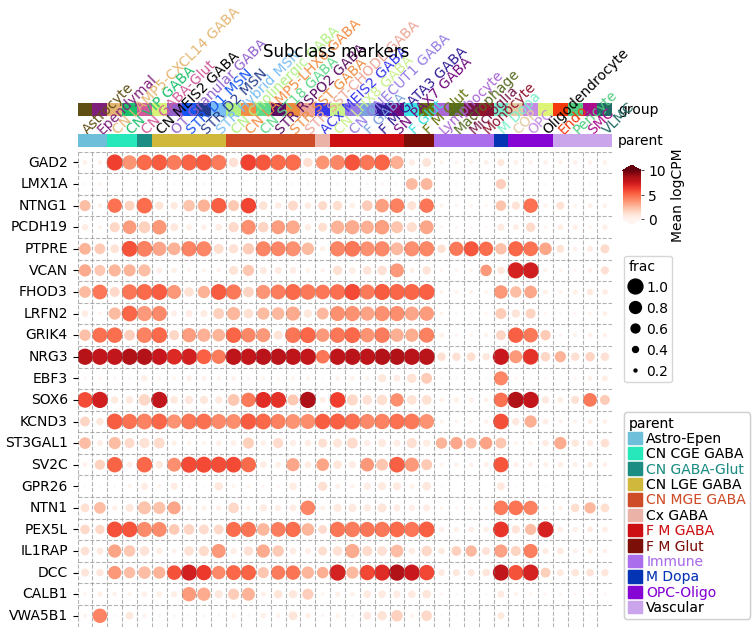

In [11]:
# Marker dot plot using gene_dotplot (rich PyComplexHeatmap wrapper).
keep_genes = [
    "GAD2", "LMX1A", "NTNG1", "PCDH19", "PTPRE", "VCAN", "FHOD3", "LRFN2",
    "GRIK4", "NRG3", "EBF3", "SOX6", "KCND3", "ST3GAL1", "SV2C", "GPR26",
    "NTN1", "PEX5L", "IL1RAP", "DCC", "CALB1", "VWA5B1",
]
gene_order = list(keep_genes)
cell_type_order = None
av.pl.gene_dotplot(
    adata=adata_path,
    genes=keep_genes,
    groupby="Subclass",
    parent_col="Class",
    modality="RNA",
    use_raw=False,
    expression_cutoff="p5",
    gene_order=gene_order,
    row_cluster=False,
    col_cluster=False,
    cmap="Reds",
    palette="~/Projects/LabData/BasalGanglia/10xMultiome/HMBA_color_palette.xlsx",
    legend_kws=dict(extendfrac=0.1, extend="both", label="Mean logCPM"),
    figsize=(7, 6),
    plot_kws=dict(
        vmin=0,
        vmax=10,
        xticklabels_kws=dict(labelrotation=-30, labelsize=10, bottom=True),
        yticklabels_kws=dict(labelsize=10, left=True),
    ),
    title="Subclass markers",
    show=True,
)


In [12]:
keep_genes = [
    # MEDIUM SPINY NEURONS (MSN) - High Confidence
    "MEIS2",
    "BCL11B",
    "PPP1R1B",
    "GNG7",
    "ADCY5",  #'EGR1','MEIS1',
    "CHRM1",
    "CHRM4",
    "GRM4",
    "KCNJ4",
    "GAD2",
    "GAD1",
    "ARPP21",
    "FOSL2",
    "RFX3",
    "FOXO3",
    "PDE10A",  #'SLC4A4','PHACTR1',  # MSN Signaling, 'NPAS2'
    "FOXP1",
    "FOXO1",
    "DRD1",  # D1-MSN (Direct Pathway)
    "DRD2",
    "ADORA2A",
    "OPRD1",  # D2-MSN (Indirect Pathway):
    # M Dopa
    "NR4A2",
    "PBX1",
    "SLC6A3",
    "TH",
    "EBF3",
    "SLC18A2",
    "LMX1A",
    "LMX1B",
    "PITX3",
    "RET",
    "KCNJ6",  #'NFIA',
    # CHOLINERGIC INTERNEURONS (ChI) - High Confidence
    "SLC18A3",
    "GRK5",
    "CHAT",
    "SLC5A7",
    "LHX6",
    "LHX8",
    "GDNF",  # 'TLE3', 'ARX', 'INPP4B','NTRK1',
    # 'ACHE', acetylcholine (ACh), degradation of acetylcholine (ACh) happen largely extracellular
]

cell_type_order = [
    "STR D1 MSN",
    "STR D2 MSN",
    "STR Hybrid MSN",
    "M Dopa",
    "CN Cholinergic GABA",
]
gene_order = keep_genes

/gale/netapp/home2/wding/Projects/Github/adataviz/adataviz/pl/expression.py:486: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  use.obs[groupby] = obs.loc[use.obs_names, groupby].tolist()


/gale/netapp/home2/wding/Software/miniconda3/envs/m3c/lib/python3.9/site-packages/PyComplexHeatmap/dotHeatmap.py:354: FutureWarning: The provided callable <function mean at 0x7f9af027cca0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data2d = data.pivot_table(
/gale/netapp/home2/wding/Software/miniconda3/envs/m3c/lib/python3.9/site-packages/PyComplexHeatmap/dotHeatmap.py:373: FutureWarning: The provided callable <function mean at 0x7f9af027cca0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.kwargs["s"] = data.pivot_table(
/gale/netapp/home2/wding/Software/miniconda3/envs/m3c/lib/python3.9/site-packages/PyComplexHeatmap/dotHeatmap.py:389: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  se

Starting plotting HeatmapAnnotations


Incresing ncol


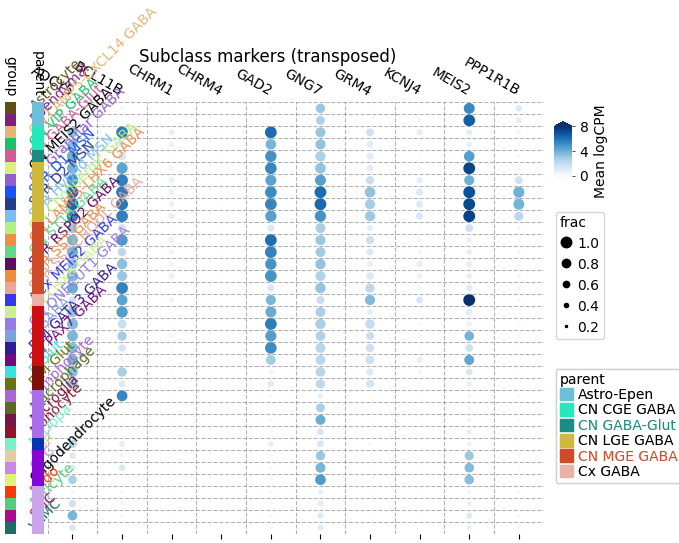

In [13]:
# Second gene_dotplot example: same genes, transposed orientation.
av.pl.gene_dotplot(
    adata=adata_path,
    genes=keep_genes[:10],
    groupby="Subclass",
    parent_col="Class",
    modality="RNA",
    use_raw=False,
    expression_cutoff="p5",
    transpose=True,
    cmap="Blues",
    palette="~/Projects/LabData/BasalGanglia/10xMultiome/HMBA_color_palette.xlsx",
    legend_kws=dict(extendfrac=0.1, extend="both", label="Mean logCPM"),
    figsize=(7, 5),
    plot_kws=dict(
        vmin=0, vmax=8,
        xticklabels_kws=dict(labelrotation=-30, labelsize=10, bottom=True),
        yticklabels_kws=dict(labelsize=9, left=True),
    ),
    title="Subclass markers (transposed)",
)


## Cell statistics plots

A family of categorical-composition plots (rose / ring / pie / area / dot /
trend / sankey / chord / venn / upset) implemented on top of matplotlib,
with a few optional extras (``matplotlib-venn``, ``upsetplot``,
``pycirclize``, ``adjustText``).

All functions accept either an :class:`anndata.AnnData` (recommended:
palettes are auto-loaded from ``adata.uns``) or a :class:`pandas.DataFrame`
/ path to a tabular file. Each function with a legend exposes a
``legend_kws`` argument that is forwarded to matplotlib.

In [14]:
import os
import warnings

import anndata
import matplotlib.pyplot as plt
import pandas as pd

import adataviz as av

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

adata_path = os.path.expanduser(
    "~/Projects/LabData/BasalGanglia/10xMultiome/HMBA.Group.downsample_1500.h5ad"
)

# Load the full AnnData so colour palettes stored in ``adata.uns``
# (e.g. ``Class_colors``, ``Group_colors``) are picked up automatically.
adata = anndata.read_h5ad(adata_path)
print("adata:", adata.shape)
print(
    "Class:",
    adata.obs["Class"].nunique(),
    "| Subclass:",
    adata.obs["Subclass"].nunique(),
    "| Group:",
    adata.obs["Group"].nunique(),
)

adata: (70134, 36601)
Class: 12 | Subclass: 36 | Group: 60


### 1. `rose_plot` – Nightingale polar bar of cell-class counts

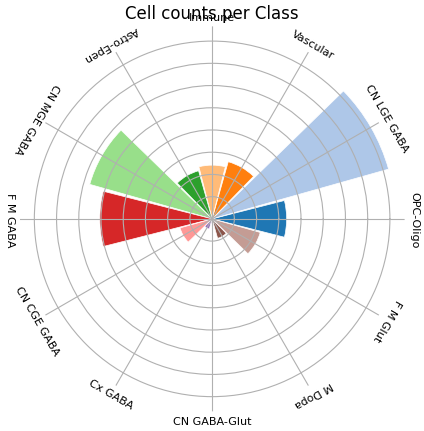

In [15]:
av.pl.rose_plot(
    adata,
    groupby="Class",
    figsize=(5, 5),
    title="Cell counts per Class",
)
plt.show()

### 2. `ring_plot` – donut chart of class proportions

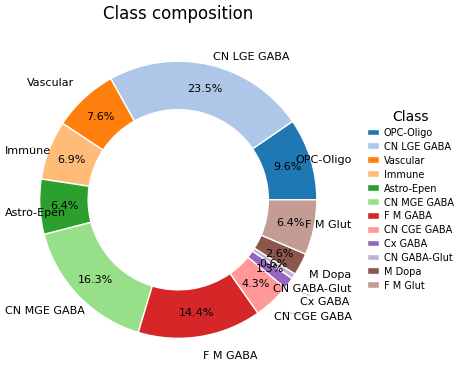

In [16]:
av.pl.ring_plot(
    adata,
    groupby="Class",
    figsize=(4.5, 4.5),
    title="Class composition",
    show_legend=True,
    adjust_text=True,  # de-overlap labels using ``adjustText`` if installed
    legend_kws=dict(fontsize=7, ncol=1),
)
plt.show()

### 3. `pie_plot` – pie chart, optionally faceted by anatomical region

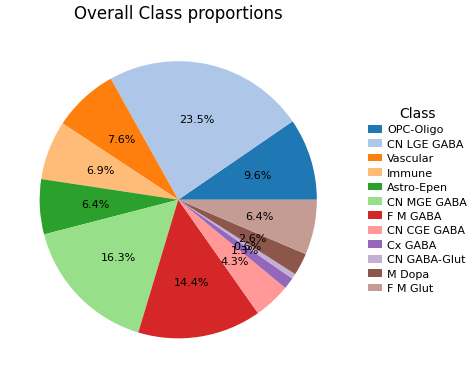

In [17]:
av.pl.pie_plot(
    adata,
    groupby="Class",
    title="Overall Class proportions",
)
plt.show()

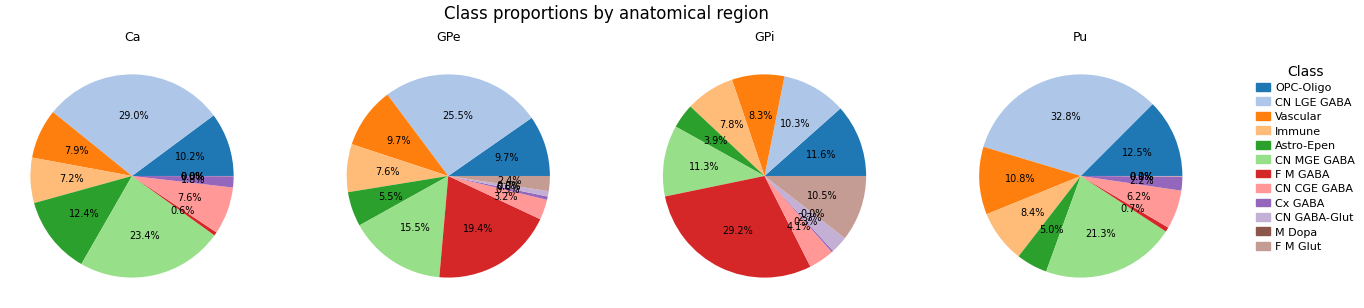

In [18]:
# Subset to the most common regions to keep the facet grid readable.
top_regions = (
    adata.obs["anatomical_region_merged"].value_counts().head(4).index.tolist()
)
sub = adata[
    adata.obs["anatomical_region_merged"].isin(top_regions)
].copy()
av.pl.pie_plot(
    sub,
    groupby="Class",
    split_by="anatomical_region_merged",
    ncols=4,
    title="Class proportions by anatomical region",
)
plt.show()

### 4. `area_plot` – stacked area showing Class composition across donors

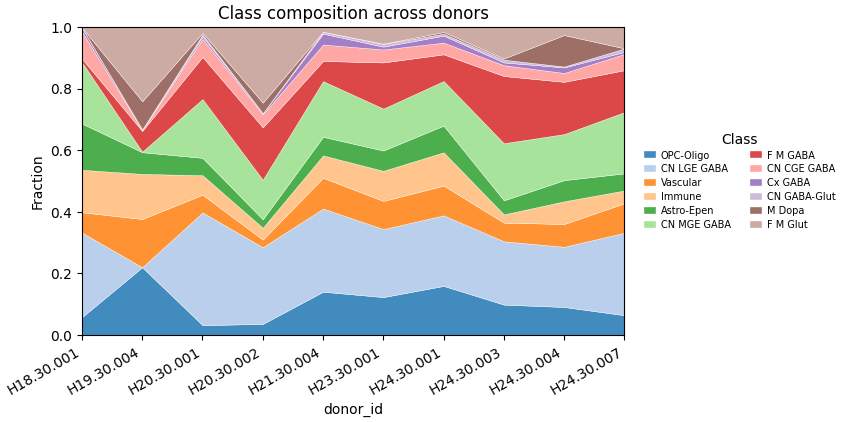

In [19]:
av.pl.area_plot(
    adata,
    groupby="Class",
    split_by="donor_id",
    figsize=(7, 4),
    title="Class composition across donors",
    legend_kws=dict(fontsize=7, ncol=2),
)
plt.show()

### 5. `dot_plot` – grid where size = count and colour = column-fraction

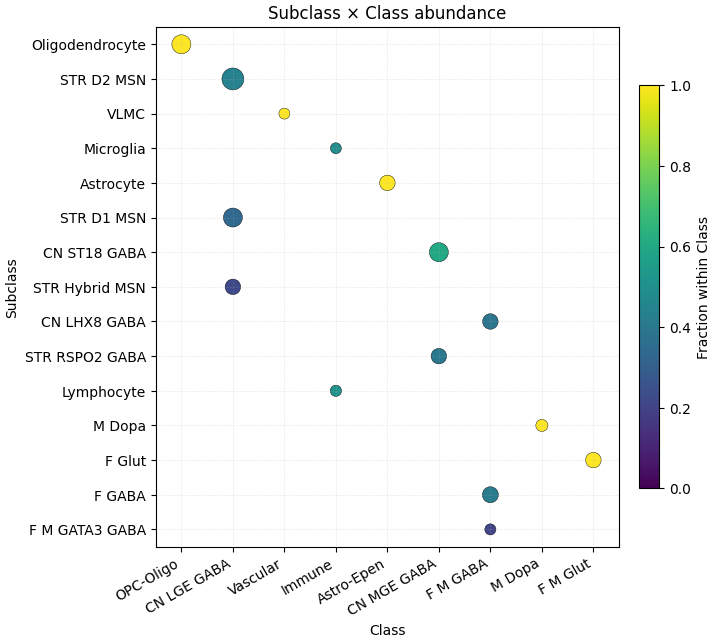

In [20]:
# Pick the top Subclasses for legibility.
top_subclasses = (
    adata.obs["Subclass"].value_counts().head(15).index.tolist()
)
sub = adata[adata.obs["Subclass"].isin(top_subclasses)].copy()
av.pl.dot_plot(
    sub,
    groupby="Subclass",
    split_by="Class",
    title="Subclass × Class abundance",
)
plt.show()

### 6. `trend_plot` – line trend of Class fraction across donors

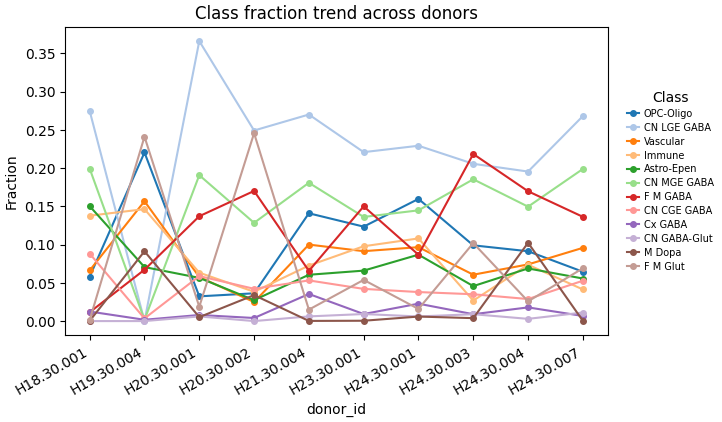

In [21]:
av.pl.trend_plot(
    adata,
    groupby="Class",
    split_by="donor_id",
    figsize=(7, 4),
    title="Class fraction trend across donors",
    legend_kws=dict(fontsize=7),
)
plt.show()

### 7. `sankey_plot` – two-column flow from Class → Group

Each Class node spans the full canvas height proportional to its size, and each ribbon meets the corresponding Group node on the right.

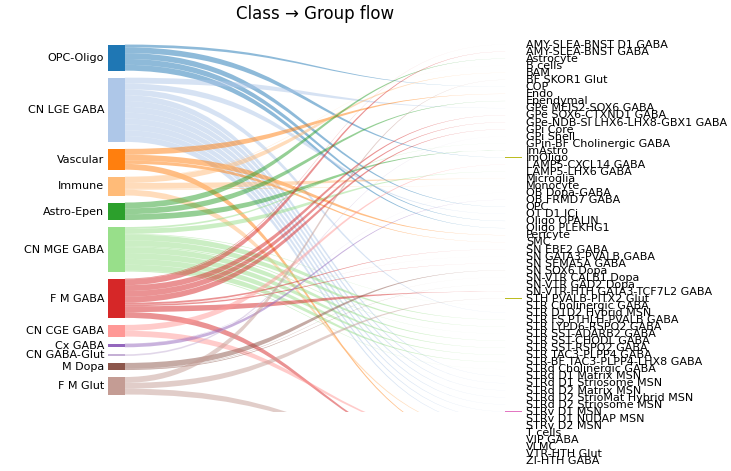

In [22]:
av.pl.sankey_plot(
    adata,
    left="Class",
    right="Group",
    figsize=(8, 5),
    title="Class → Group flow",
)
plt.show()

### 8. `chord_plot` – circular co-occurrence between Class and region

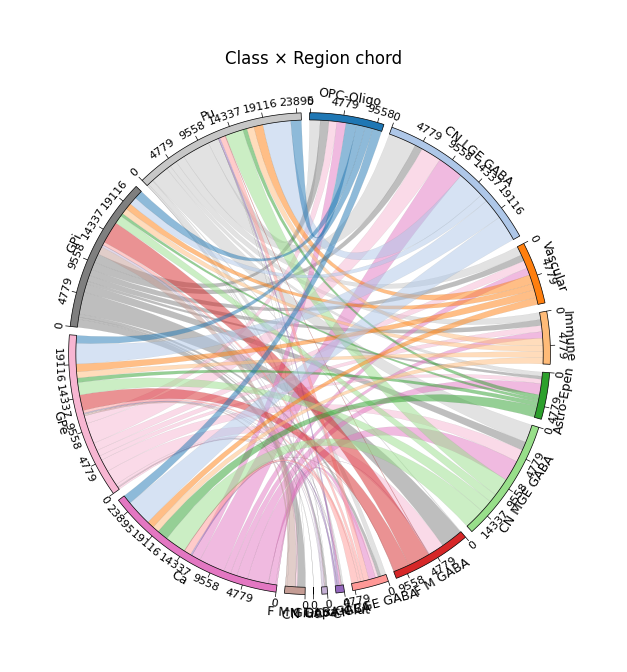

In [23]:
sub = adata[
    adata.obs["anatomical_region_merged"].isin(top_regions)
].copy()
av.pl.chord_plot(
    sub,
    left="Class",
    right="anatomical_region_merged",
    figsize=(6, 6),
    title="Class × Region chord",
)
plt.show()

### 9. `venn_plot` – Subclasses present in each Class

Take the top three Classes by cell count and look at which Subclasses occur in each.

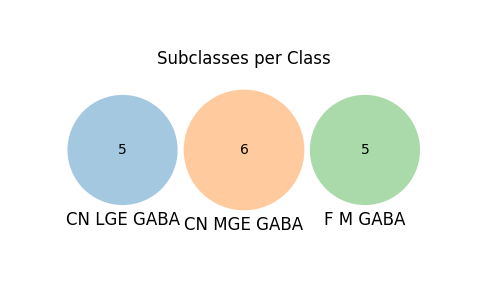

In [24]:
top_classes = adata.obs["Class"].value_counts().head(3).index.tolist()
sub = adata[adata.obs["Class"].isin(top_classes)].copy()
av.pl.venn_plot(
    sub,
    groupby="Class",
    set_by="Subclass",
    figsize=(5, 5),
    title="Subclasses per Class",
)
plt.show()

### 10. `upset_plot` – overlap of Subclasses across Classes

Useful when there are >3 sets and Venn becomes unreadable.

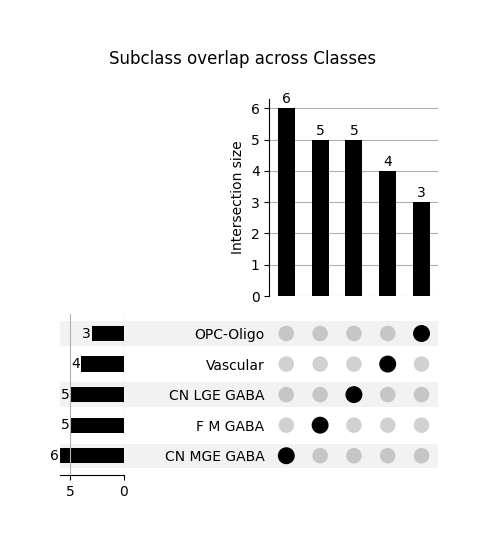

In [25]:
top_classes = adata.obs["Class"].value_counts().head(5).index.tolist()
sub = adata[adata.obs["Class"].isin(top_classes)].copy()
fig = av.pl.upset_plot(
    sub,
    groupby="Class",
    set_by="Subclass",
    figsize=(9, 4.5),
    title="Subclass overlap across Classes",
)
plt.show()

### 11. `complex_heatmap` – PyComplexHeatmap clustered heatmap of mean gene expression per Class

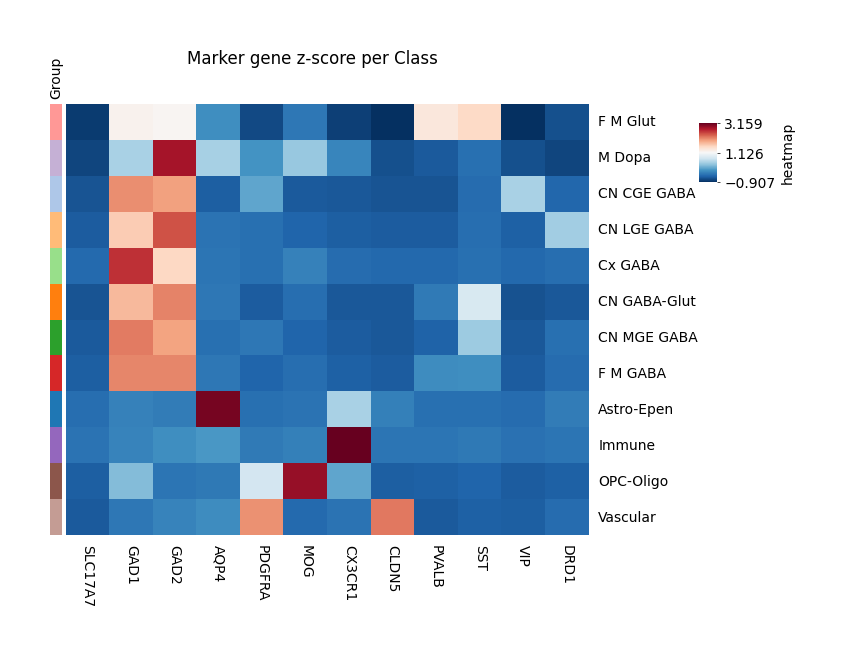

In [26]:
marker_genes = [
    g for g in [
        "SLC17A7", "GAD1", "GAD2", "AQP4", "PDGFRA", "MOG",
        "CX3CR1", "CLDN5", "PVALB", "SST", "VIP", "DRD1",
    ]
    if g in adata.var_names
]
av.pl.complex_heatmap(
    adata,
    genes=marker_genes,
    groupby="Class",
    z_score="row",
    figsize=(7, 5),
    title="Marker gene z-score per Class",
)
plt.show()

### 12. `complex_dotplot` – PyComplexHeatmap dot heatmap (size = % expressing, colour = mean expression)

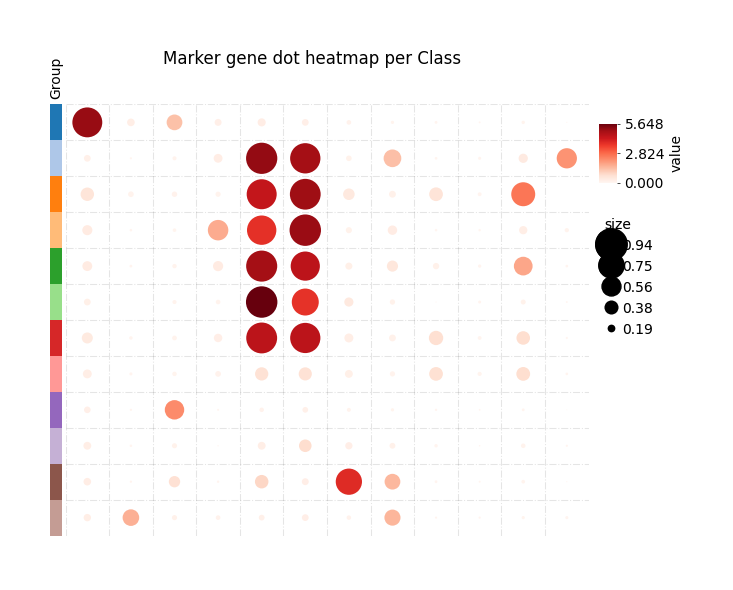

In [27]:
av.pl.complex_dotplot(
    adata,
    genes=marker_genes,
    groupby="Class",
    figsize=(7, 5),
    title="Marker gene dot heatmap per Class",
)
plt.show()